In [2]:
!pip install -q moabb

In [3]:
import mne
import moabb
import tensorflow as tf
import sklearn

print("MNE:", mne.__version__)
print("MOABB:", moabb.__version__)
print("TensorFlow:", tf.__version__)
print("scikit-learn:", sklearn.__version__)
print("GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)

MNE: 1.13.2
MOABB: 1.7.2
TensorFlow: 2.20.0
scikit-learn: 1.6.1
GPU available: True


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery

SUBJECT = 1            # The dataset has 9 subjects; we start with subject 1
FMIN, FMAX = 8, 30     # Frequency band of interest in Hz
TMIN, TMAX = 0.5, 2.5  # Time window after the cue, in seconds

In [5]:
dataset = BNCI2014_001()
paradigm = LeftRightImagery(fmin=FMIN, fmax=FMAX, tmin=TMIN, tmax=TMAX)

X, labels, meta = paradigm.get_data(dataset=dataset, subjects=[SUBJECT])

print("X shape:", X.shape)
print("Labels:", np.unique(labels, return_counts=True))
print(meta.head())
print("Sessions:", meta["session"].unique())


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
This is nemar-py 0.3.2.
Preparing to download nm000139 from https://data.nemar.org/
Retrieving 5 of 769 manifest files (16 concurrent downloads).


Overall:   0%|          | 0.00/12.6k [00:00<?, ?B/s]

Finished downloading nm000139 v1.0.2.
This is nemar-py 0.3.2.
Preparing to download nm000139 from https://data.nemar.org/
Retrieving 6 of 769 manifest files (16 concurrent downloads).


S3:   0%|          | 0.00/82.6M [00:00<?, ?B/s]

Finished downloading nm000139 v1.0.2.


/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/di

X shape: (288, 22, 501)
Labels: (array(['left_hand', 'right_hand'], dtype='<U10'), array([144, 144]))
   subject session run
0        1  0train   0
1        1  0train   0
2        1  0train   0
3        1  0train   0
4        1  0train   0
Sessions: ['0train' '1test']


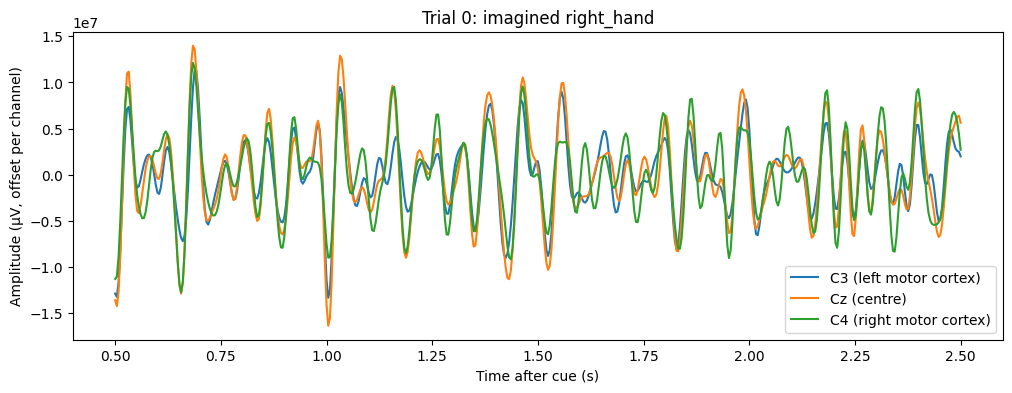

In [6]:
fs = 250  # Sampling rate in Hz
time = np.arange(X.shape[2]) / fs + TMIN
channels = {"C3 (left motor cortex)": 7, "Cz (centre)": 9, "C4 (right motor cortex)": 11}

plt.figure(figsize=(12, 4))
for offset, (name, idx) in enumerate(channels.items()):
    plt.plot(time, X[0, idx] * 1e6 + offset * 40, label=name)
plt.title(f"Trial 0: imagined {labels[0]}")
plt.xlabel("Time after cue (s)")
plt.ylabel("Amplitude (µV, offset per channel)")
plt.legend()
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(labels)

LEFT = int(encoder.transform(["left_hand"])[0])
RIGHT = int(encoder.transform(["right_hand"])[0])

print("Classes:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
print("Encoded labels (first 10):", y[:10])

Classes: {np.str_('left_hand'): np.int64(0), np.str_('right_hand'): np.int64(1)}
Encoded labels (first 10): [1 0 0 1 1 0 0 0 1 1]


In [8]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(labels)

LEFT = int(encoder.transform(["left_hand"])[0])
RIGHT = int(encoder.transform(["right_hand"])[0])

print("Classes:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
print("Encoded labels (first 10):", y[:10])

Classes: {np.str_('left_hand'): np.int64(0), np.str_('right_hand'): np.int64(1)}
Encoded labels (first 10): [1 0 0 1 1 0 0 0 1 1]


In [12]:
sessions = sorted(meta["session"].unique())

train_mask = (meta["session"] == sessions[0]).to_numpy()
test_mask = (meta["session"] == sessions[1]).to_numpy()

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (144, 22, 501)
Test: (144, 22, 501)


In [13]:


channel_mean = X_train.mean(axis=(0, 2), keepdims=True)
channel_std = X_train.std(axis=(0, 2), keepdims=True) + 1e-8

X_train_n = ((X_train - channel_mean) / channel_std).astype("float32")
X_test_n = ((X_test - channel_mean) / channel_std).astype("float32")

print("Before normalisation, train std:", X_train.std())
print("After normalisation,  train std:", X_train_n.std())

Before normalisation, train std: 4.551635602724293
After normalisation,  train std: 0.9999999


In [14]:
from sklearn.model_selection import train_test_split

SEED = 42
idx_tr, idx_val = train_test_split(
    np.arange(len(y_train)), test_size=0.2, stratify=y_train, random_state=SEED
)

print(f"Training trials: {len(idx_tr)} | Validation trials: {len(idx_val)}")
print("Validation class counts:", np.bincount(y_train[idx_val]))

Training trials: 115 | Validation trials: 29
Validation class counts: [15 14]


In [15]:
from sklearn.metrics import accuracy_score, cohen_kappa_score

results = {}
predictions = {}

def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    results[name] = {"accuracy": acc, "kappa": kappa}
    predictions[name] = y_pred
    print(f"{name}: accuracy = {acc:.3f} | kappa = {kappa:.3f}")

In [16]:
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_model = Pipeline([
    ("csp", CSP(n_components=6, log=True, norm_trace=False)),
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=SEED)),
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
evaluate("CSP+SVM", y_test, y_pred_svm)

Computing rank from data with rank=None
    Using tolerance 25 (2.2e-16 eps * 22 dim * 5.1e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
CSP+SVM: accuracy = 0.847 | kappa = 0.694


In [17]:
import random
import tensorflow as tf
from tensorflow.keras import layers, models, constraints, callbacks

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def train_keras(model, X_tr, X_te, epochs, patience):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=patience,
                                         restore_best_weights=True)
    history = model.fit(X_tr[idx_tr], y_train[idx_tr],
                        validation_data=(X_tr[idx_val], y_train[idx_val]),
                        epochs=epochs, batch_size=16,
                        callbacks=[early_stop], verbose=0)
    print(f"Stopped after {len(history.history['loss'])} epochs")
    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    return history, y_pred

In [18]:
def build_eegnet(n_ch, n_t, n_classes=2, F1=8, D=2, F2=16, dropout=0.5):
    inputs = layers.Input(shape=(n_ch, n_t, 1))

    # Block 1a: temporal filters learn frequency patterns (like the 8-30 Hz rhythms)
    x = layers.Conv2D(F1, (1, 64), padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)

    # Block 1b: spatial filters learn which channels matter (a learned version of CSP)
    x = layers.DepthwiseConv2D((n_ch, 1), depth_multiplier=D, use_bias=False,
                               depthwise_constraint=constraints.max_norm(1.0))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.AveragePooling2D((1, 4))(x)
    x = layers.Dropout(dropout)(x)

    # Block 2: combines the learned patterns over time
    x = layers.SeparableConv2D(F2, (1, 16), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.AveragePooling2D((1, 8))(x)
    x = layers.Dropout(dropout)(x)

    # Classifier
    x = layers.Flatten()(x)
    outputs = layers.Dense(n_classes, activation="softmax",
                           kernel_constraint=constraints.max_norm(0.25))(x)
    return models.Model(inputs, outputs, name="EEGNet")

In [19]:
set_seed()
X_train_cnn = X_train_n[..., np.newaxis]
X_test_cnn = X_test_n[..., np.newaxis]

eegnet = build_eegnet(X_train.shape[1], X_train.shape[2])
cnn_history, y_pred_cnn = train_keras(eegnet, X_train_cnn, X_test_cnn,
                                      epochs=300, patience=40)
evaluate("EEGNet", y_test, y_pred_cnn)

Stopped after 233 epochs
EEGNet: accuracy = 0.854 | kappa = 0.708


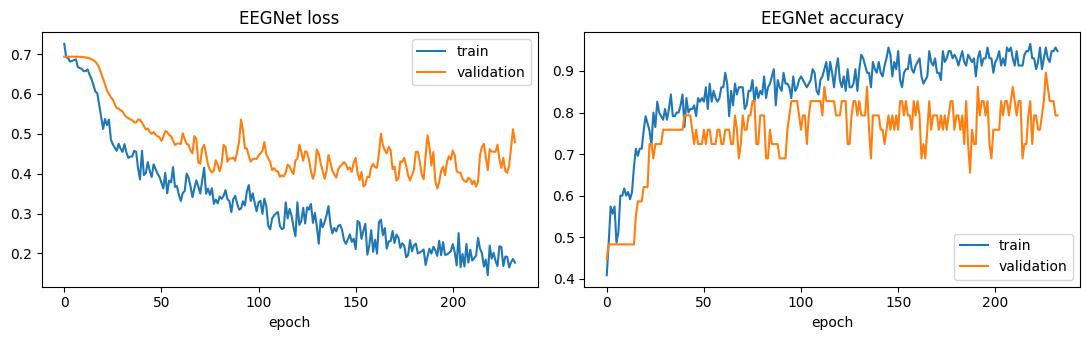

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for key, axis in zip(["loss", "accuracy"], ax):
    axis.plot(cnn_history.history[key], label="train")
    axis.plot(cnn_history.history[f"val_{key}"], label="validation")
    axis.set_title(f"EEGNet {key}")
    axis.set_xlabel("epoch")
    axis.legend()
plt.tight_layout()
plt.show()

In [21]:
DECIMATION = 4
X_train_seq = X_train_n[:, :, ::DECIMATION].transpose(0, 2, 1)
X_test_seq = X_test_n[:, :, ::DECIMATION].transpose(0, 2, 1)

print("LSTM input shape:", X_train_seq.shape)

LSTM input shape: (144, 126, 22)


In [22]:
def build_lstm(n_steps, n_ch, n_classes=2):
    inputs = layers.Input(shape=(n_steps, n_ch))
    x = layers.LSTM(64)(inputs)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return models.Model(inputs, outputs, name="LSTM")

set_seed()
lstm = build_lstm(X_train_seq.shape[1], X_train_seq.shape[2])
lstm_history, y_pred_lstm = train_keras(lstm, X_train_seq, X_test_seq,
                                        epochs=150, patience=25)
evaluate("LSTM", y_test, y_pred_lstm)

Stopped after 26 epochs
LSTM: accuracy = 0.521 | kappa = 0.042


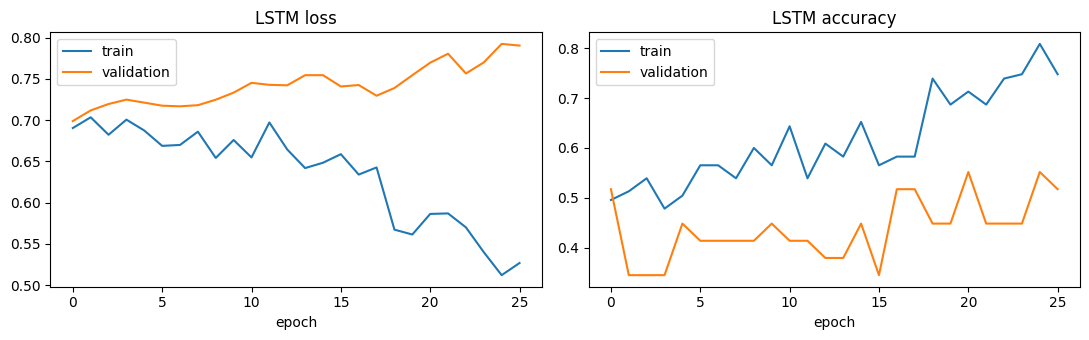

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for key, axis in zip(["loss", "accuracy"], ax):
    axis.plot(lstm_history.history[key], label="train")
    axis.plot(lstm_history.history[f"val_{key}"], label="validation")
    axis.set_title(f"LSTM {key}")
    axis.set_xlabel("epoch")
    axis.legend()
plt.tight_layout()
plt.show()

In [24]:
WINDOW = 25                              # 25 samples = 100 ms at 250 Hz
n_win = X_train_n.shape[2] // WINDOW     # 20 windows per trial

def power_sequence(X):
    X = X[:, :, :n_win * WINDOW]
    power = (X ** 2).reshape(X.shape[0], X.shape[1], n_win, WINDOW).mean(axis=3)
    return np.log(power + 1e-8).transpose(0, 2, 1)

X_train_pow = power_sequence(X_train_n)
X_test_pow = power_sequence(X_test_n)

pow_mean = X_train_pow.mean(axis=(0, 1), keepdims=True)
pow_std = X_train_pow.std(axis=(0, 1), keepdims=True) + 1e-8
X_train_pow = ((X_train_pow - pow_mean) / pow_std).astype("float32")
X_test_pow = ((X_test_pow - pow_mean) / pow_std).astype("float32")

print("Power sequence shape:", X_train_pow.shape)

Power sequence shape: (144, 20, 22)


Stopped after 31 epochs


LSTM-power: accuracy = 0.549 | kappa = 0.097


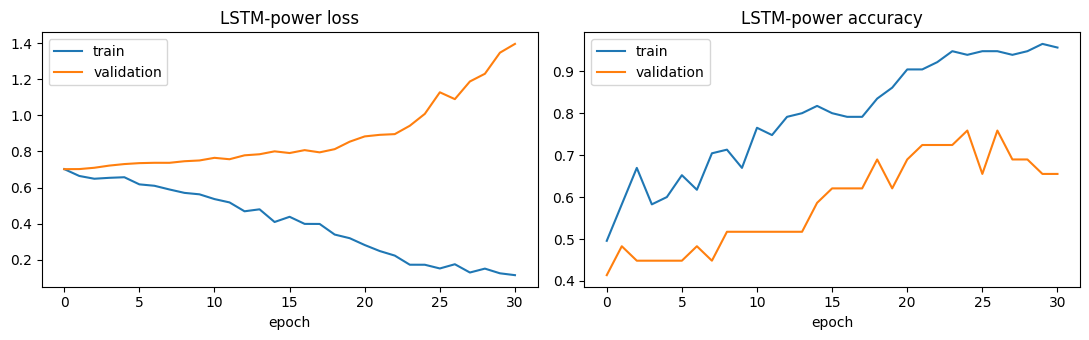

In [25]:
set_seed()
lstm_pow = build_lstm(X_train_pow.shape[1], X_train_pow.shape[2])
lstm_pow_history, y_pred_lstm_pow = train_keras(lstm_pow, X_train_pow, X_test_pow,
                                                epochs=200, patience=30)
evaluate("LSTM-power", y_test, y_pred_lstm_pow)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for key, axis in zip(["loss", "accuracy"], ax):
    axis.plot(lstm_pow_history.history[key], label="train")
    axis.plot(lstm_pow_history.history[f"val_{key}"], label="validation")
    axis.set_title(f"LSTM-power {key}")
    axis.set_xlabel("epoch")
    axis.legend()
plt.tight_layout()
plt.show()

In [26]:
csp_seq = CSP(n_components=6, transform_into="csp_space", norm_trace=False)
csp_seq.fit(X_train[idx_tr], y_train[idx_tr])

X_train_csp = power_sequence(csp_seq.transform(X_train))
X_test_csp = power_sequence(csp_seq.transform(X_test))

csp_mean = X_train_csp.mean(axis=(0, 1), keepdims=True)
csp_std = X_train_csp.std(axis=(0, 1), keepdims=True) + 1e-8
X_train_csp = ((X_train_csp - csp_mean) / csp_std).astype("float32")
X_test_csp = ((X_test_csp - csp_mean) / csp_std).astype("float32")

print("CSP power sequence shape:", X_train_csp.shape)

Computing rank from data with rank=None
    Using tolerance 22 (2.2e-16 eps * 22 dim * 4.6e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
CSP power sequence shape: (144, 20, 6)


Stopped after 34 epochs
CSP+LSTM: accuracy = 0.875 | kappa = 0.750


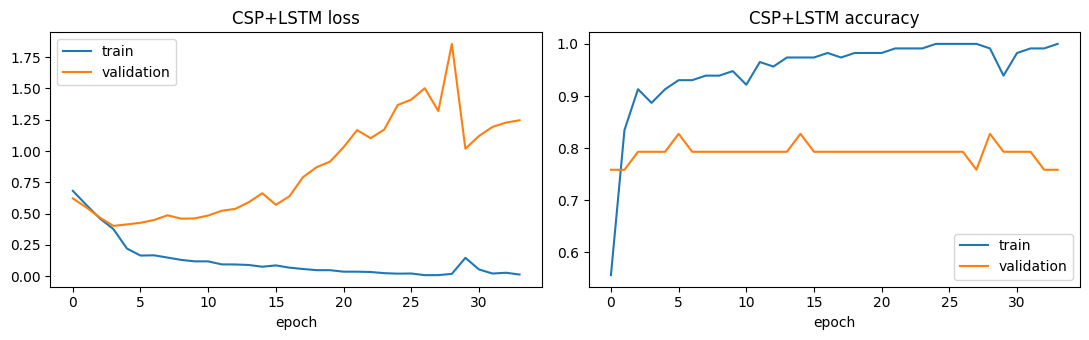

In [27]:
set_seed()
lstm_csp = build_lstm(X_train_csp.shape[1], X_train_csp.shape[2])
lstm_csp_history, y_pred_lstm_csp = train_keras(lstm_csp, X_train_csp, X_test_csp,
                                                epochs=200, patience=30)
evaluate("CSP+LSTM", y_test, y_pred_lstm_csp)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for key, axis in zip(["loss", "accuracy"], ax):
    axis.plot(lstm_csp_history.history[key], label="train")
    axis.plot(lstm_csp_history.history[f"val_{key}"], label="validation")
    axis.set_title(f"CSP+LSTM {key}")
    axis.set_xlabel("epoch")
    axis.legend()
plt.tight_layout()
plt.show()

            accuracy  kappa  correct_trials
CSP+LSTM       0.875  0.750             126
EEGNet         0.854  0.708             123
CSP+SVM        0.847  0.694             122
LSTM-power     0.549  0.097              79
LSTM           0.521  0.042              75


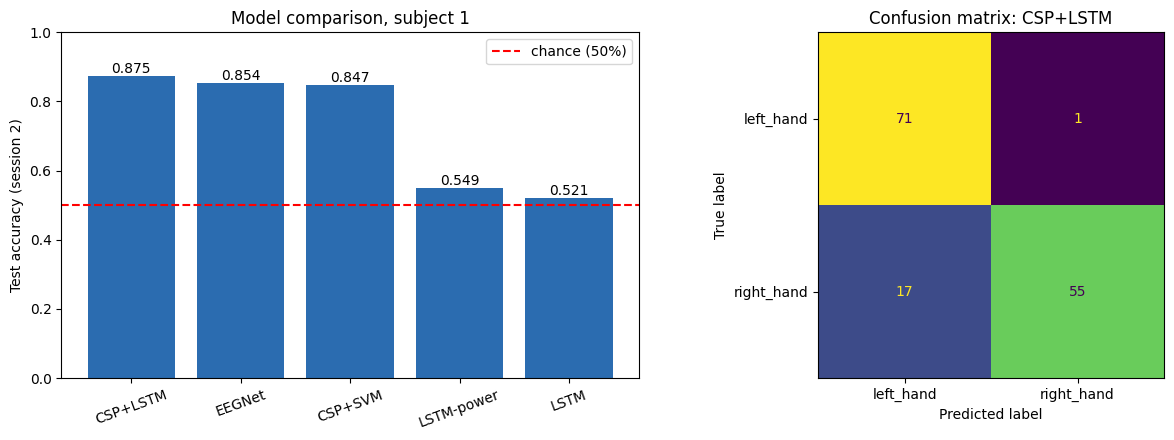

In [28]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

summary = pd.DataFrame(results).T.sort_values("accuracy", ascending=False)
summary["correct_trials"] = (summary["accuracy"] * len(y_test)).round().astype(int)
print(summary.round(3))

best_name = summary.index[0]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

bars = ax[0].bar(summary.index, summary["accuracy"], color="#2b6cb0")
ax[0].axhline(0.5, linestyle="--", color="red", label="chance (50%)")
ax[0].bar_label(bars, fmt="%.3f")
ax[0].set_ylim(0, 1)
ax[0].set_ylabel("Test accuracy (session 2)")
ax[0].set_title(f"Model comparison, subject {SUBJECT}")
ax[0].tick_params(axis="x", rotation=20)
ax[0].legend()

cm = confusion_matrix(y_test, predictions[best_name])
ConfusionMatrixDisplay(cm, display_labels=encoder.classes_).plot(ax=ax[1], colorbar=False)
ax[1].set_title(f"Confusion matrix: {best_name}")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

summary.round(3).to_csv("results_subject1.csv")

In [29]:
N_STEPS = 40          # Number of test trials to replay
TURN_DEG = 30.0       # Degrees turned per command
STEP_SIZE = 1.0       # Distance moved per command

def simulate_path(commands):
    x, y_pos, heading = 0.0, 0.0, 90.0   # Start at origin, facing up
    path = [(x, y_pos)]
    for cmd in commands:
        heading += TURN_DEG if cmd == LEFT else -TURN_DEG
        x += STEP_SIZE * np.cos(np.radians(heading))
        y_pos += STEP_SIZE * np.sin(np.radians(heading))
        path.append((x, y_pos))
    return np.array(path)

intended_cmds = y_test[:N_STEPS]
decoded_cmds = predictions[best_name][:N_STEPS]

intended_path = simulate_path(intended_cmds)
robot_path = simulate_path(decoded_cmds)

n_correct = int((intended_cmds == decoded_cmds).sum())
print(f"Model driving the robot: {best_name}")
print(f"Correct commands: {n_correct} of {N_STEPS}")

Model driving the robot: CSP+LSTM
Correct commands: 37 of 40


In [31]:
from matplotlib import animation
from IPython.display import HTML, display

fig, ax = plt.subplots(figsize=(7, 7))
all_pts = np.vstack([intended_path, robot_path])
ax.set_xlim(all_pts[:, 0].min() - 2, all_pts[:, 0].max() + 2)
ax.set_ylim(all_pts[:, 1].min() - 2, all_pts[:, 1].max() + 2)
ax.set_aspect("equal")
ax.grid(alpha=0.3)

ax.plot(intended_path[:, 0], intended_path[:, 1], "--", color="gray", label="intended path")
trail, = ax.plot([], [], "-", color="#2b6cb0", lw=2, label=f"robot path ({best_name})")
robot, = ax.plot([], [], "o", color="#2b6cb0", ms=14)
title = ax.set_title("")
ax.legend(loc="upper right")
names = {LEFT: "LEFT", RIGHT: "RIGHT"}

def update(frame):
    trail.set_data(robot_path[:frame + 1, 0], robot_path[:frame + 1, 1])
    robot.set_data([robot_path[frame, 0]], [robot_path[frame, 1]])
    if frame == 0:
        robot.set_color("#2b6cb0")
        title.set_text("Start")
    else:
        i = frame - 1
        ok = intended_cmds[i] == decoded_cmds[i]
        robot.set_color("#2b6cb0" if ok else "red")
        title.set_text(f"Trial {frame}: imagined {names[intended_cmds[i]]}, "
                       f"decoded {names[decoded_cmds[i]]} "
                       f"({'correct' if ok else 'WRONG'})")
    return trail, robot, title

anim = animation.FuncAnimation(fig, update, frames=N_STEPS + 1, interval=500)
plt.close(fig)

anim.save("robot_demo.gif", writer="pillow", fps=2)
display(HTML(anim.to_jshtml()))

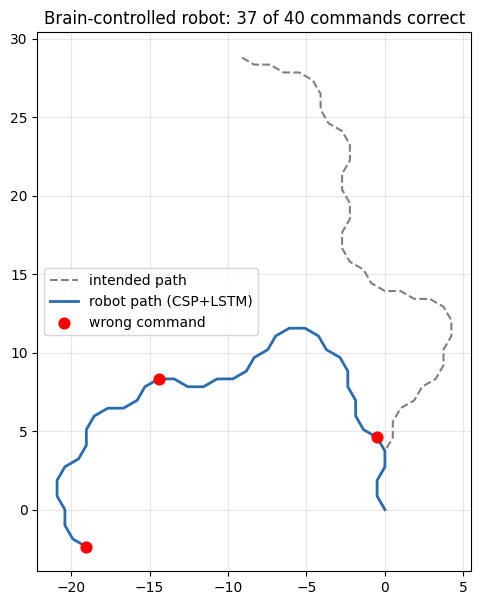

In [32]:
plt.figure(figsize=(7, 7))
plt.plot(intended_path[:, 0], intended_path[:, 1], "--", color="gray", label="intended path")
plt.plot(robot_path[:, 0], robot_path[:, 1], "-", color="#2b6cb0", lw=2, label=f"robot path ({best_name})")

wrong = np.where(intended_cmds != decoded_cmds)[0] + 1
plt.scatter(robot_path[wrong, 0], robot_path[wrong, 1], color="red", s=60, zorder=3, label="wrong command")

plt.gca().set_aspect("equal")
plt.grid(alpha=0.3)
plt.legend()
plt.title(f"Brain-controlled robot: {n_correct} of {N_STEPS} commands correct")
plt.savefig("robot_path.png", dpi=150)
plt.show()